# 🤖 Deep Learning Pipeline: Image Data (Roboflow)
Notebook ini berfokus pada tahap *Feature Engineering* (Image Preprocessing & Augmentation) serta pelatihan model *Computer Vision* menggunakan arsitektur **Convolutional Neural Network (CNN)** untuk mendeteksi indikator fisik stunting pada balita.

## Import Library untuk Deep Learning (TensorFlow/Keras)

In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Mengunci langsung ke sub-folder train dan valid bawaan Roboflow
IMAGE_TRAIN_DIR = '../data/processed/gambar/train/'
IMAGE_VAL_DIR = '../data/processed/gambar/valid/'

print("✅ Library terimport dan Path dataset citra terarah dengan benar!")
print(f"TensorFlow Version: {tf.__version__}")

✅ Library terimport dan Path dataset citra terarah dengan benar!
TensorFlow Version: 2.21.0


## Image Preprocessing & Augmentation (Feature Engineering Gambar)

In [24]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("⚙️ Mengonfigurasi Data Augmentation untuk Gambar...")

# Augmentasi moderat agar tidak merusak esensi klinis objek fisik anak
train_datagen = ImageDataGenerator(
    rescale=1./255,          
    rotation_range=15,       
    width_shift_range=0.1,   
    height_shift_range=0.1,  
    horizontal_flip=True,    
    fill_mode='nearest'
)

# Data validasi murni hanya di-rescale pikselnya saja tanpa augmentasi
val_datagen = ImageDataGenerator(rescale=1./255)

# Load data training
train_generator = train_datagen.flow_from_directory(
    IMAGE_TRAIN_DIR,         
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=42
)

# Load data validasi
val_generator = val_datagen.flow_from_directory(
    IMAGE_VAL_DIR,           
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=42
)

print(f"\n🎯 SUCCESS! Kelas medis yang terdeteksi sekarang: {list(train_generator.class_indices.keys())}")

⚙️ Mengonfigurasi Data Augmentation untuk Gambar...
Found 1695 images belonging to 3 classes.
Found 334 images belonging to 3 classes.

🎯 SUCCESS! Kelas medis yang terdeteksi sekarang: ['Healthy', 'MalNutrisi', 'Stunting']


## Visualisasi Gambar Hasil Augmentasi

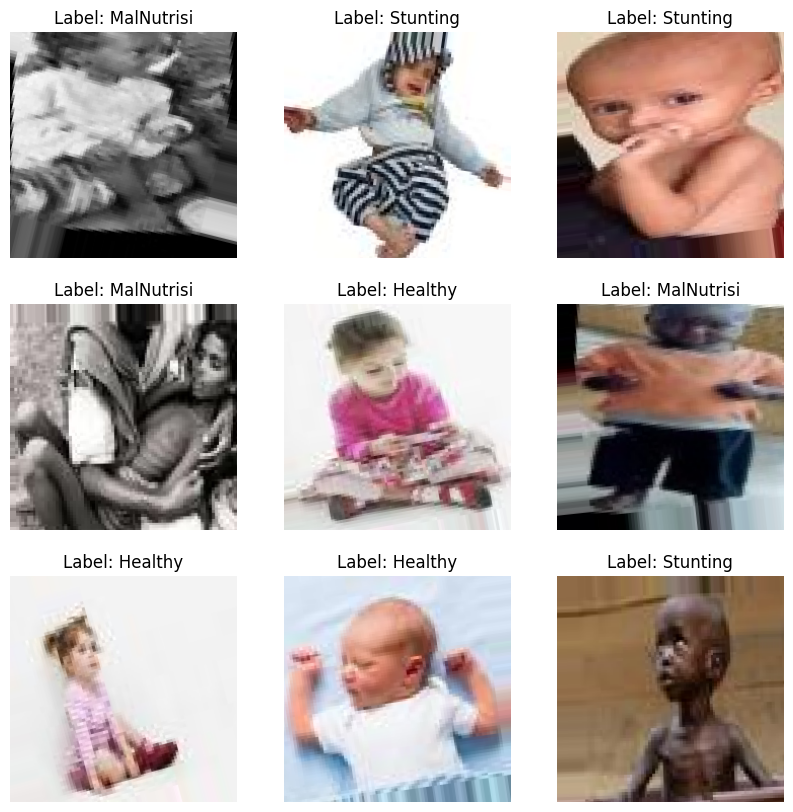

In [25]:
# Mengambil satu batch sampel untuk memastikan label sudah sesuai foto
images, labels = next(train_generator)

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    # Mengambil nama kelas berdasarkan index label terbesar
    class_name = list(train_generator.class_indices.keys())[np.argmax(labels[i])]
    plt.title(f"Label: {class_name}")
    plt.axis('off')
plt.show()

## Membangun Arsitektur CNN (The "Cooking" Stage)

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization

print("⚙️ Membangun arsitektur Scratch CNN penjinak overfitting...")

model_cnn = Sequential([
    # Block Convolutional 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block Convolutional 2
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block Convolutional 3
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Menggantikan Flatten() dengan GAP agar jumlah parameter terkontrol
    GlobalAveragePooling2D(),
    
    # Fully Connected Layer (Otak Keputusan)
    Dense(64, activation='relu'),
    Dropout(0.5), # Mencegah model menghafal pixel mati
    Dense(3, activation='softmax') # Output 3 kelas
])

print("✅ Arsitektur CNN buatan sendiri siap digunakan!")

⚙️ Membangun arsitektur Scratch CNN penjinak overfitting...
✅ Arsitektur CNN buatan sendiri siap digunakan!


## Training Model CNN

In [28]:
from tensorflow.keras.optimizers import Adam
from sklearn.utils import class_weight

print("⚙️ Menghitung penyeimbang bobot kelas (Class Weights)...")
class_indices = train_generator.classes
classes_to_weight = np.unique(class_indices)
computed_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=classes_to_weight,
    y=class_indices
)
class_weights_dict = dict(zip(classes_to_weight, computed_weights))
print(f"⚖️ Bobot penyeimbang kelas: {class_weights_dict}\n")

# Kompilasi dengan learning rate teliti (0.0001)
model_cnn.compile(
    optimizer=Adam(learning_rate=0.0001), 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

model_cnn.summary()

# Menjalankan training selama 30 epoch dulu untuk tes ombak
print("\n⏳ Memulai proses Training CNN Medis (30 Epoch)...")
history = model_cnn.fit(
    train_generator,
    epochs=35, 
    validation_data=val_generator,
    class_weight=class_weights_dict, # Memaksa model adil pada kelas minoritas
    verbose=1
)
print("✅ Training selesai!")

⚙️ Menghitung penyeimbang bobot kelas (Class Weights)...
⚖️ Bobot penyeimbang kelas: {np.int32(0): np.float64(0.9201954397394136), np.int32(1): np.float64(1.0272727272727273), np.int32(2): np.float64(1.064030131826742)}



Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,595 (400.76 KB)

 Trainable params: 102,147 (399.01 KB)

 Non-trainable params: 448 (1.75 KB)


⏳ Memulai proses Training CNN Medis (30 Epoch)...
Epoch 1/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 40s 717ms/step - accuracy: 0.8496 - loss: 0.4049 - val_accuracy: 0.8383 - val_loss: 0.4860
Epoch 2/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 40s 750ms/step - accuracy: 0.8496 - loss: 0.3971 - val_accuracy: 0.8054 - val_loss: 0.5048
Epoch 3/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 40s 754ms/step - accuracy: 0.8608 - loss: 0.3915 - val_accuracy: 0.8174 - val_loss: 0.5194
Epoch 4/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 41s 773ms/step - accuracy: 0.8478 - loss: 0.3904 - val_accuracy: 0.8234 - val_loss: 0.5241
Epoch 5/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 41s 769ms/step - accuracy: 0.8466 - loss: 0.4020 - val_accuracy: 0.8503 - val_loss: 0.4833
Epoch 6/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 42s 783ms/step - accuracy: 0.8649 - loss: 0.3706 - val_accuracy: 0.8024 - val_loss: 0.5460
Epoch 7/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 42s 780ms/step - accuracy: 0.8661 - loss: 0.3852 - val_accuracy: 0.8323 - val_loss: 0.4811
Epoch 8/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 43s 800m

## Evaluasi Akurasi AI

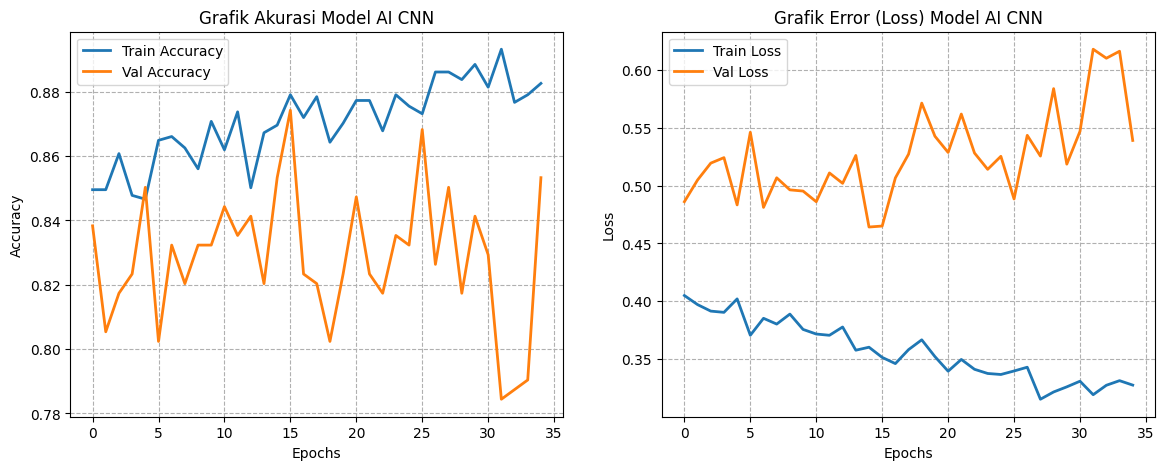

In [30]:
plt.figure(figsize=(14, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='tab:blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='tab:orange', linewidth=2)
plt.title('Grafik Akurasi Model AI CNN', fontsize=12)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='tab:blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', color='tab:orange', linewidth=2)
plt.title('Grafik Error (Loss) Model AI CNN', fontsize=12)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--')

plt.show()

## Menyimpan Model AI (.h5)

In [32]:
model_save_path = '../models/cnn_stunting_vision_model.keras'
model_cnn.save(model_save_path)
print(f"🏁 SUCCESS: Model AI Visi Komputer berhasil disimpan di: \n   {model_save_path}")

🏁 SUCCESS: Model AI Visi Komputer berhasil disimpan di: 
   ../models/cnn_stunting_vision_model.keras
